# Smooth effects on SSM parameters with `hsgp()`

Sometimes a model parameter varies with a covariate in a way you do not want
to commit to parametrically — drift that drifts over trial time, a threshold
that collapses over the session, sensitivity that is a smooth function of
stimulus strength. Bambi's `hsgp()` formula term (a Hilbert-space approximate
Gaussian process) covers exactly this, and it works in any HSSM regression
formula.

In this tutorial we simulate a DDM whose drift follows $v(s) = A\,\sin(s)$ in
a stimulus variable, then recover that curve with

```python
"formula": "v ~ 0 + hsgp(stim, m=10, c=2)"
```

In [1]:
import logging
import warnings

import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np

import hssm

warnings.filterwarnings("ignore")
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)

## Simulate data with a smooth drift effect

Drift varies with the stimulus as $v(s) = A\,\sin(s)$; all other parameters
are constant. `hssm.simulate_data` accepts trial-wise parameters as 1D arrays
(one entry per trial) — with trial-wise parameters, `size` counts replications
*per trial*, so `size=1` yields one row per trial.

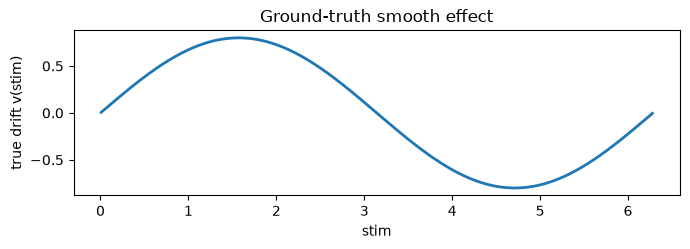

In [2]:
amplitude = 0.8
n_trials = 800

rng = np.random.default_rng(42)
stim = rng.uniform(0.0, 2.0 * np.pi, n_trials)
v_true = amplitude * np.sin(stim)

data = hssm.simulate_data(
    model="ddm",
    theta={
        "v": v_true,
        "a": np.full_like(v_true, 1.5),
        "z": np.full_like(v_true, 0.5),
        "t": np.full_like(v_true, 0.3),
    },
    size=1,
    random_state=42,
)
data["stim"] = stim

order = np.argsort(stim)
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.plot(stim[order], v_true[order], lw=2)
ax.set(xlabel="stim", ylabel="true drift v(stim)", title="Ground-truth smooth effect")
fig.tight_layout()

## Specifying the model

An HSGP term's prior is a **dictionary of covariance-function priors** —
typically the amplitude `sigma` and the lengthscale `ell` — exactly as in
bambi. Everything else in the regression keeps HSSM's usual prior styles.

Two equivalent alternatives: give the covariance parameters as JSON-able dict
specs (`{"sigma": {"name": "Exponential", "lam": 3.0}, ...}`), or omit the
`hsgp(...)` key entirely to use bambi's automatic HSGP priors.

In [3]:
HSGP_TERM = "hsgp(stim, m=10, c=2)"

model = hssm.HSSM(
    data=data,
    model="ddm",
    include=[
        {
            "name": "v",
            "formula": f"v ~ 0 + {HSGP_TERM}",
            "prior": {
                HSGP_TERM: {
                    "sigma": bmb.Prior("Exponential", lam=3.0),
                    "ell": bmb.Prior("InverseGamma", mu=2.0, sigma=0.2),
                },
            },
        }
    ],
    loglik_kind="analytical",
)
model

Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 800

Parameters:

v:
    Formula: v ~ 0 + hsgp(stim, m=10, c=2)
    Priors:
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)

z:
    Prior: Uniform(lower: 0.0, upper: 1.0)
    Explicit bounds: (0.0, 1.0)

t:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)


Lapse probability: 0.05
Lapse distribution: Uniform(lower: 0.0, upper: 20.0)

## Fit

In [4]:
idata = model.sample(
    draws=150,
    tune=150,
    chains=2,
    cores=1,
)

Using default initvals. 



Initializing NUTS using adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [a, t, z, v_hsgp(stim, m=10, c=2)_sigma, v_hsgp(stim, m=10, c=2)_ell, v_hsgp(stim, m=10, c=2)_weights_raw]


Output()

Sampling 2 chains for 150 tune and 150 draw iterations (300 + 300 draws total) took 21 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


## Recovering the smooth effect

The per-observation GP contribution is exposed in the posterior under the
term's own name; we compare its posterior mean and 90% credible band with
the ground truth.

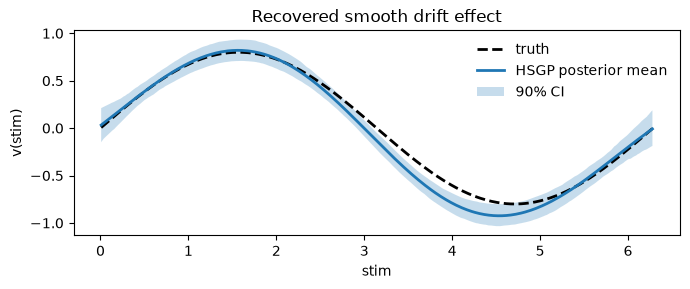

In [5]:
contrib = idata.posterior[f"v_{HSGP_TERM}"]
gp_mean = contrib.mean(("chain", "draw")).values
gp_lo = contrib.quantile(0.05, ("chain", "draw")).values
gp_hi = contrib.quantile(0.95, ("chain", "draw")).values

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(stim[order], v_true[order], "k--", lw=2, label="truth")
ax.plot(stim[order], gp_mean[order], lw=2, label="HSGP posterior mean")
ax.fill_between(stim[order], gp_lo[order], gp_hi[order], alpha=0.25, label="90% CI")
ax.set(xlabel="stim", ylabel="v(stim)", title="Recovered smooth drift effect")
ax.legend(frameon=False)
fig.tight_layout()

## What the posterior contains

The fit exposes the full HSGP decomposition — amplitude, lengthscale, basis
weights, and the per-observation GP contribution:

In [6]:
sorted(v for v in idata.posterior.data_vars if HSGP_TERM in v)

['v_hsgp(stim, m=10, c=2)',
 'v_hsgp(stim, m=10, c=2)_ell',
 'v_hsgp(stim, m=10, c=2)_sigma',
 'v_hsgp(stim, m=10, c=2)_weights',
 'v_hsgp(stim, m=10, c=2)_weights_raw']